In [1]:
%matplotlib inline

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

In [3]:
class TwoDigitMNIST(Dataset):
    def __init__(self,train=True):
        self.mnist=datasets.MNIST(
            root="data",
            train=train,
            download=True,
            transform=ToTensor(),
        )

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self,idx):
      idx=torch.randint(len(self.mnist),(1,)).item()
      img1,label1=self.mnist[idx]

      idx2=torch.randint(len(self.mnist),(1,)).item()
      img2,label2=self.mnist[idx2]

      top=torch.cat([img1,img2],dim=2)
      bottom=torch.zeros_like(top)
      img=torch.cat([top,bottom],dim=1)

      target=0 if label2%2==0 else 1

      return img,target

In [4]:
from torch.utils.data import DataLoader, random_split
batch_size = 64

# 全体（train=True のみ）
full_dataset = TwoDigitMNIST(train=True)

# 分割比率
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# 分割
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
# テストデータをダウンロード
test_data = TwoDigitMNIST(train=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [5]:
batch_size = 64

# # データローダーの作成
# train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print("Shape of X [N, C, H, W]: ", X.shape)
    print("Shape of y: ", y.shape, y.dtype)
    break

Shape of X [N, C, H, W]:  torch.Size([64, 1, 56, 56])
Shape of y:  torch.Size([64]) torch.int64


In [6]:
# 訓練に際して、可能であればGPU（cuda）を設定します。GPUが搭載されていない場合はCPUを使用します
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

class CNN(nn.Module):
    def __init__(self):     #モデルの設計図
        super().__init__()

        # 畳み込み層
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU()
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 2)

    # def forward(self, x):
    #     x = self.conv_stack(x)
    #     x = self.fc_stack(x)
    #     return x
    def forward(self, x):      #上のを使った処理の流れ
        feature_map = self.features(x)
        gap = self.gap(feature_map)
        gap = gap.view(gap.size(0), -1)
        out = self.fc(gap)
        return out
model = CNN().to(device)
print(model)


Using cuda device
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [7]:
# # 訓練に際して、可能であればGPU（cuda）を設定します。GPUが搭載されていない場合はCPUを使用します
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Using {} device".format(device))

# # modelを定義します
# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super(NeuralNetwork, self).__init__()
#         self.flatten = nn.Flatten()
#         self.linear_relu_stack = nn.Sequential(
#              nn.Linear(28*56, 512),
#              nn.ReLU(),
#              nn.Linear(512, 512),
#              nn.ReLU(),
#              nn.Linear(512, 2),
#         )

#     def forward(self, x):
#         x = self.flatten(x)
#         logits = self.linear_relu_stack(x)
#         return logits

# model = NeuralNetwork().to(device)
# print(model)

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.008)

In [9]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    train_loss = 0.0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 損失誤差を計算
        pred = model(X) #予測（0.8とか）を出力
        loss = loss_fn(pred, y) #損失関数で誤差を計算

        # バックプロパゲーション
        optimizer.zero_grad() #0にリセットする
        loss.backward() #lossの勾配の計算
        optimizer.step() #重みの更新

        train_loss += loss.item()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    return train_loss / len(dataloader)

In [10]:
def validate(dataloader, model, loss_fn):
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            val_loss += loss.item()

    return val_loss / len(dataloader)

In [11]:
def test(dataloader, model):
    size = len(dataloader.dataset)
    model.eval() #testだから重みを変えない
    test_loss, correct = 0, 0
    with torch.no_grad(): #testだから勾配を計算しなくていい　逆伝播をしなくていい
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= size
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [12]:
epochs = 100    #更新する数
patience = 100   # 何epoch改善しなければ止めるか
# train_losses = []
# val_losses = []
# for t in range(epochs):
#     print(f"Epoch {t+1}\n-------------------------------")
#     train_loss = train(train_loader, model, loss_fn, optimizer)
#     val_loss = validate(val_loader, model, loss_fn)

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)

# test(test_dataloader, model)
# print("Done!")
#early stopping を使っていい感じのところで止めてmodelを保存する
#精度もレポートに含める


best_val_loss = float("inf")
early_stop_counter = 0
best_model_saved = False

train_losses = []
val_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train_loss = train(train_loader, model, loss_fn, optimizer)
    val_loss = validate(val_loader, model, loss_fn)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    # ===== Early Stopping 判定 =====
    if not best_model_saved:
      if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0

        # ベストモデルを保存
        torch.save(model.state_dict(), "best_model.pth")
        print("  → Best model saved")
      else:
        early_stop_counter += 1
        print(f"  → No improvement ({early_stop_counter}/{patience})")

      if early_stop_counter >= patience:
        best_model_saved = True   #ほんとはTrueにしたら途中で学習を止める
        print("Best model fixed")
    else:
      print("  Only recording")

print("Training finished")

# ===== ベストモデルを読み込んでテスト =====
model.load_state_dict(torch.load("best_model.pth"))
test(test_dataloader, model)

print("Done!")


Epoch 1
-------------------------------
loss: 0.694938  [    0/48000]
loss: 0.686908  [ 6400/48000]
loss: 0.684462  [12800/48000]
loss: 0.696648  [19200/48000]
loss: 0.692182  [25600/48000]
loss: 0.692491  [32000/48000]
loss: 0.693467  [38400/48000]
loss: 0.693477  [44800/48000]
Train loss: 0.6931, Val loss: 0.6927
  → Best model saved
Epoch 2
-------------------------------
loss: 0.690486  [    0/48000]
loss: 0.689307  [ 6400/48000]
loss: 0.689805  [12800/48000]
loss: 0.686275  [19200/48000]
loss: 0.692957  [25600/48000]
loss: 0.696410  [32000/48000]
loss: 0.695928  [38400/48000]
loss: 0.689956  [44800/48000]
Train loss: 0.6927, Val loss: 0.6926
  → Best model saved
Epoch 3
-------------------------------
loss: 0.687436  [    0/48000]
loss: 0.691316  [ 6400/48000]
loss: 0.695534  [12800/48000]
loss: 0.692771  [19200/48000]
loss: 0.691572  [25600/48000]
loss: 0.686209  [32000/48000]
loss: 0.691919  [38400/48000]
loss: 0.692636  [44800/48000]
Train loss: 0.6925, Val loss: 0.6925
  → Bes

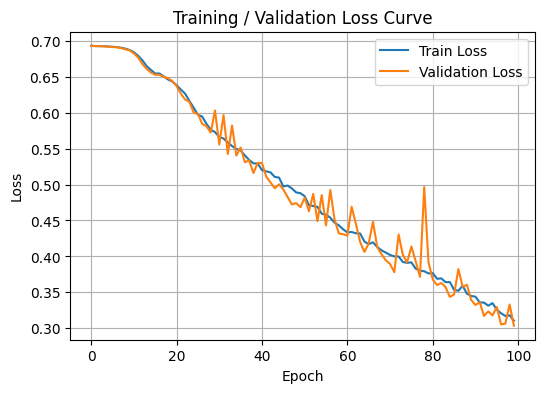

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

#これはよゆうがあったらレポートに入れる

In [14]:
def compute_cam(model, x, target_class):
    model.eval()

    with torch.no_grad():
        feature_map = model.features(x)  # [1, C, H, W]

    weights = model.fc.weight[target_class]  # [C]

    cam = torch.zeros(feature_map.shape[2:], device=x.device)
    for i in range(weights.shape[0]):
        cam += weights[i] * feature_map[0, i]

    cam = cam.detach().cpu().numpy()
    cam -= cam.min()
    cam /= cam.max()

    return cam

In [15]:
# torch.save(model.state_dict(), "model.pth")
# print("Saved PyTorch Model State to model.pth")
# #epoch　のとｋろに入れる　best.pthみたいなの

In [16]:
model = CNN().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [17]:
class TwoDigitMNISTVis(Dataset):
    def __init__(self, train=False):
        self.mnist = datasets.MNIST(
            root="data",
            train=train,
            download=True,
            transform=ToTensor(),
        )

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        idx1 = torch.randint(len(self.mnist), (1,)).item()
        img1, label1 = self.mnist[idx1]

        idx2 = torch.randint(len(self.mnist), (1,)).item()
        img2, label2 = self.mnist[idx2]

        img = torch.cat([img1, img2], dim=2)
        target = 0 if label2 % 2 == 0 else 1

        return img, target, img1, img2, label2
vis_data=TwoDigitMNISTVis(train=False)

Predicted: Odd, Actual: Odd


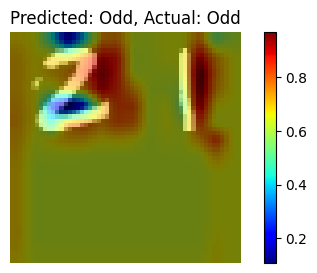

In [115]:
classes = ["Even", "Odd"]
import torch
from torchvision import transforms
import torch.nn.functional as F




model.eval()
x, y = test_data[0]
x = x.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(x)
    pred_class = output.argmax(1).item()

print(f"Predicted: {classes[pred_class]}, Actual: {classes[y]}")




cam = compute_cam(model, x, pred_class)   # numpy (h, w)
cam = torch.from_numpy(cam).float()       # tensor (h, w)

img = x[0, 0].cpu().numpy()                # (56, 56)
H, W = img.shape

# (h, w) → (1, 1, h, w)
cam = cam.unsqueeze(0).unsqueeze(0)
img = x[0, 0].cpu().numpy()

# plt.figure(figsize=(6,3))
# plt.imshow(img, cmap="gray")
# plt.imshow(cam, cmap="jet", alpha=0.5)
# plt.colorbar()
# plt.title(f"Predicted: {classes[pred_class]}, Actual: {classes[y]}")
# plt.axis("off")
# plt.show()

plt.figure(figsize=(6,3))

# ① CAM を背景として表示
cam_resized = F.interpolate(
    cam,
    size=(H, W),
    mode="bilinear",
    align_corners=False
)

resize_cam = cam_resized[0, 0].cpu().numpy()


plt.imshow(resize_cam, cmap="jet")
plt.colorbar()

# ② 元の数字画像を透かして重ねる
plt.imshow(img, cmap="gray", alpha=0.5)
plt.title(f"Predicted: {classes[pred_class]}, Actual: {classes[y]}")
plt.axis("off")
plt.show()

#重ねて表示した画像をレポートに入れる